# Enhanced MLX-LM Fine-tuning with Learning Rate Scheduling (v2)

This notebook implements improved fine-tuning techniques with a simpler approach that works with MLX's training system.

In [15]:
!pip install sentencepiece transformers datasets
!pip install tiktoken

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [16]:
import json
import os
import math
from typing import Dict, List, Optional, Tuple, Union
import numpy as np
import matplotlib.pyplot as plt
import mlx.core as mx
import mlx.optimizers as optim
from mlx.utils import tree_flatten
from mlx_lm import generate, load
from mlx_lm.tuner import TrainingArgs, datasets, linear_to_lora_layers, train
from transformers import PreTrainedTokenizer

## 1. Learning Rate Scheduler with Callback Integration

In [17]:
class LRSchedulerCallback:
    """Callback that adjusts learning rate during training"""
    
    def __init__(self, optimizer, base_lr: float, min_lr: float, 
                 warmup_steps: int, total_steps: int, 
                 schedule_type: str = "cosine"):
        self.optimizer = optimizer
        self.base_lr = base_lr
        self.min_lr = min_lr
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.schedule_type = schedule_type
        self.current_step = 0
        
        # Tracking
        self.train_losses: List[Tuple[int, float]] = []
        self.val_losses: List[Tuple[int, float]] = []
        self.learning_rates: List[Tuple[int, float]] = []
        self.plateau_count = 0
        self.best_val_loss = float('inf')
        
    def get_lr(self, step: int) -> float:
        """Calculate learning rate for current step"""
        if step < self.warmup_steps:
            return self.base_lr * (step / self.warmup_steps)
        
        progress = (step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
        progress = min(1.0, progress)
        
        if self.schedule_type == "cosine":
            lr = self.min_lr + (self.base_lr - self.min_lr) * \
                 0.5 * (1 + math.cos(math.pi * progress))
        elif self.schedule_type == "cosine_restarts":
            # Cosine with warm restarts every 150 steps
            cycle_steps = 150
            cycle = (step - self.warmup_steps) // cycle_steps
            cycle_progress = ((step - self.warmup_steps) % cycle_steps) / cycle_steps
            
            # Decay base LR over cycles
            cycle_base_lr = self.base_lr * (0.8 ** cycle)
            lr = self.min_lr + (cycle_base_lr - self.min_lr) * \
                 0.5 * (1 + math.cos(math.pi * cycle_progress))
        else:
            lr = self.base_lr
            
        return lr
    
    def on_train_loss_report(self, info: Dict[str, Union[float, int]]) -> None:
        """Called after each training step"""
        iteration = info["iteration"]
        loss = info["train_loss"]
        
        self.train_losses.append((iteration, loss))
        
        # Update learning rate
        new_lr = self.get_lr(iteration)
        self.optimizer.learning_rate = new_lr
        self.learning_rates.append((iteration, new_lr))
        self.current_step = iteration
        
        # Check for plateau and boost LR if needed
        if len(self.train_losses) > 50:
            recent_losses = [l[1] for l in self.train_losses[-50:]]
            loss_std = np.std(recent_losses)
            if loss_std < 0.001 and self.plateau_count < 3:
                # Plateau detected - boost learning rate
                boosted_lr = min(new_lr * 2, self.base_lr)
                self.optimizer.learning_rate = boosted_lr
                self.plateau_count += 1
                print(f"\nPlateau detected at step {iteration}, boosting LR to {boosted_lr:.2e}")
    
    def on_val_loss_report(self, info: Dict[str, Union[float, int]]) -> None:
        """Called after validation"""
        iteration = info["iteration"]
        val_loss = info["val_loss"]
        self.val_losses.append((iteration, val_loss))
        
        # Track best validation loss
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
    
    def plot_training_curves(self):
        """Plot training metrics"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Plot losses
        if self.train_losses:
            train_its, train_vals = zip(*self.train_losses)
            ax1.plot(train_its, train_vals, 'b-', alpha=0.7, label='Train Loss')
        if self.val_losses:
            val_its, val_vals = zip(*self.val_losses)
            ax1.plot(val_its, val_vals, 'orange', marker='o', label='Validation Loss')
        ax1.set_xlabel('Iteration')
        ax1.set_ylabel('Loss')
        ax1.set_title('Training and Validation Loss')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot learning rate
        if self.learning_rates:
            lr_its, lr_vals = zip(*self.learning_rates)
            ax2.plot(lr_its, lr_vals, 'g-')
            ax2.set_xlabel('Iteration')
            ax2.set_ylabel('Learning Rate')
            ax2.set_title('Learning Rate Schedule')
            ax2.grid(True, alpha=0.3)
            ax2.set_yscale('log')
        
        plt.tight_layout()
        plt.show()

## 2. Load Model and Configure Enhanced LoRA

In [18]:
# Load model
model_path = "Qwen/Qwen3-1.7B-Base"
model, tokenizer = load(model_path)

# Enhanced LoRA configuration
enhanced_lora_config = {
    "num_layers": 16,  # More layers for adaptation
    "lora_parameters": {
        "rank": 32,  # Higher rank for more expressiveness
        "scale": 64.0,  # alpha = 2 * rank
        "dropout": 0.05,  # Regularization
    },
}

# Setup directories
adapter_path = "adapters_enhanced_v2"
os.makedirs(adapter_path, exist_ok=True)
adapter_config_path = os.path.join(adapter_path, "adapter_config.json")
adapter_file_path = os.path.join(adapter_path, "adapters.safetensors")

# Save configuration
with open(adapter_config_path, "w") as f:
    json.dump(enhanced_lora_config, f, indent=4)

# Apply LoRA to model
model.freeze()
linear_to_lora_layers(
    model, 
    enhanced_lora_config["num_layers"], 
    enhanced_lora_config["lora_parameters"]
)

# Count parameters
num_train_params = sum(v.size for _, v in tree_flatten(model.trainable_parameters()))
total_params = sum(v.size for _, v in tree_flatten(model.parameters()))
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {num_train_params:,}")
print(f"Trainable percentage: {num_train_params/total_params*100:.2f}%")

model.train()

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Total parameters: 1,724,244,992
Trainable parameters: 3,670,016
Trainable percentage: 0.21%


Model(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 2048)
    (layers.0): TransformerBlock(
      (self_attn): Attention(
        (q_proj): Linear(input_dims=2048, output_dims=2048, bias=False)
        (k_proj): Linear(input_dims=2048, output_dims=1024, bias=False)
        (v_proj): Linear(input_dims=2048, output_dims=1024, bias=False)
        (o_proj): Linear(input_dims=2048, output_dims=2048, bias=False)
        (q_norm): RMSNorm(128, eps=1e-06)
        (k_norm): RMSNorm(128, eps=1e-06)
        (rope): RoPE(128, traditional=False)
      )
      (mlp): MLP(
        (gate_proj): Linear(input_dims=2048, output_dims=6144, bias=False)
        (down_proj): Linear(input_dims=6144, output_dims=2048, bias=False)
        (up_proj): Linear(input_dims=2048, output_dims=6144, bias=False)
      )
      (input_layernorm): RMSNorm(2048, eps=1e-06)
      (post_attention_layernorm): RMSNorm(2048, eps=1e-06)
    )
    (layers.1): TransformerBlock(
      (self_attn): Attention(
        (

## 3. Load Dataset

In [19]:
from datasets import load_dataset
from mlx_lm.tuner.datasets import CacheDataset

def custom_load_hf_dataset(
    data_id: str,
    tokenizer: PreTrainedTokenizer,
    config: TrainingArgs = None,
    names: Tuple[str, str, str] = ("train", "valid", "test"),
):
    if config is None:
        config = TrainingArgs()

    dataset = load_dataset(data_id)
    train, valid, test = [
        (
            datasets.create_dataset(dataset[n], tokenizer, config)
            if n in dataset.keys()
            else []
        )
        for n in names
    ]
    return train, valid, test

# Load dataset
train_set, val_set, test_set = custom_load_hf_dataset(
    data_id="mlx-community/wikisql",
    tokenizer=tokenizer,
    names=("train", "valid", "test")
)

print(f"Training samples: {len(train_set)}")
print(f"Validation samples: {len(val_set)}")

Training samples: 1000
Validation samples: 100


## 4. Training with Enhanced Configuration

In [20]:
# Training configuration
training_args = TrainingArgs(
    adapter_file=adapter_file_path,
    iters=200,
    steps_per_eval=25,  # Frequent evaluation
    steps_per_save=100,  # Save every 100 steps
    batch_size=4,
    val_batches=25,  # Number of validation batches
    steps_per_report=10,  # Report every 10 steps
)

# Create optimizer with higher initial learning rate
initial_lr = 5e-5  # Higher than default 1e-5
optimizer = optim.AdamW(
    learning_rate=initial_lr,
    weight_decay=0.01  # L2 regularization
)

# Create scheduler callback
scheduler_callback = LRSchedulerCallback(
    optimizer=optimizer,
    base_lr=initial_lr,
    min_lr=1e-6,
    warmup_steps=50,
    total_steps=training_args.iters,
    schedule_type="cosine_restarts"  # Use cosine with restarts
)

print("Starting enhanced training...")
print(f"Initial learning rate: {initial_lr}")
print(f"Schedule type: cosine with warm restarts")
print(f"Weight decay: 0.01")
print(f"LoRA rank: {enhanced_lora_config['lora_parameters']['rank']}")
print(f"Evaluation every {training_args.steps_per_eval} steps")

# Train the model
train(
    model=model,
    args=training_args,
    optimizer=optimizer,
    train_dataset=CacheDataset(train_set),
    val_dataset=CacheDataset(val_set),
    training_callback=scheduler_callback,
)

Starting enhanced training...
Initial learning rate: 5e-05
Schedule type: cosine with warm restarts
Weight decay: 0.01
LoRA rank: 32
Evaluation every 25 steps
Starting training..., iters: 200


Calculating loss...: 100%|██████████| 25/25 [00:07<00:00,  3.17it/s]

Iter 1: Val loss 2.384, Val took 7.902s


Iter 10: Train loss 1.641, Learning Rate 5.000e-05, It/sec 1.799, Tokens/sec 667.030, Trained Tokens 3707, Peak mem 12.502 GB
Iter 20: Train loss 1.379, Learning Rate 1.000e-05, It/sec 1.824, Tokens/sec 686.484, Trained Tokens 7471, Peak mem 12.502 GB


Calculating loss...: 100%|██████████| 25/25 [00:07<00:00,  3.19it/s]

...

Iter 175: Val loss 1.068, Val took 7.765s


Iter 180: Train loss 1.011, Learning Rate 5.679e-06, It/sec 1.830, Tokens/sec 684.176, Trained Tokens 65055, Peak mem 12.913 GB
Iter 190: Train loss 0.889, Learning Rate 3.118e-06, It/sec 1.773, Tokens/sec 690.238, Trained Tokens 68948, Peak mem 13.293 GB


Calculating loss...: 100%|██████████| 25/25 [00:07<00:00,  3.22it/s]

Iter 200: Val loss 1.064, Val took 7.775s


Iter 200: Train loss 0.939, Learning Rate 1.535e-06, It/sec 1.878, Tokens/sec 679.847, Trained Tokens 72568, Peak mem 13.293 GB
Iter 200: Saved adapter weights to adapters_enhanced_v2/adapters.safetensors and adapters_enhanced_v2/0000200_adapters.safetensors.
Saved final weights to adapters_enhanced_v2/adapters.safetensors.


## 5. Analyze Training Results

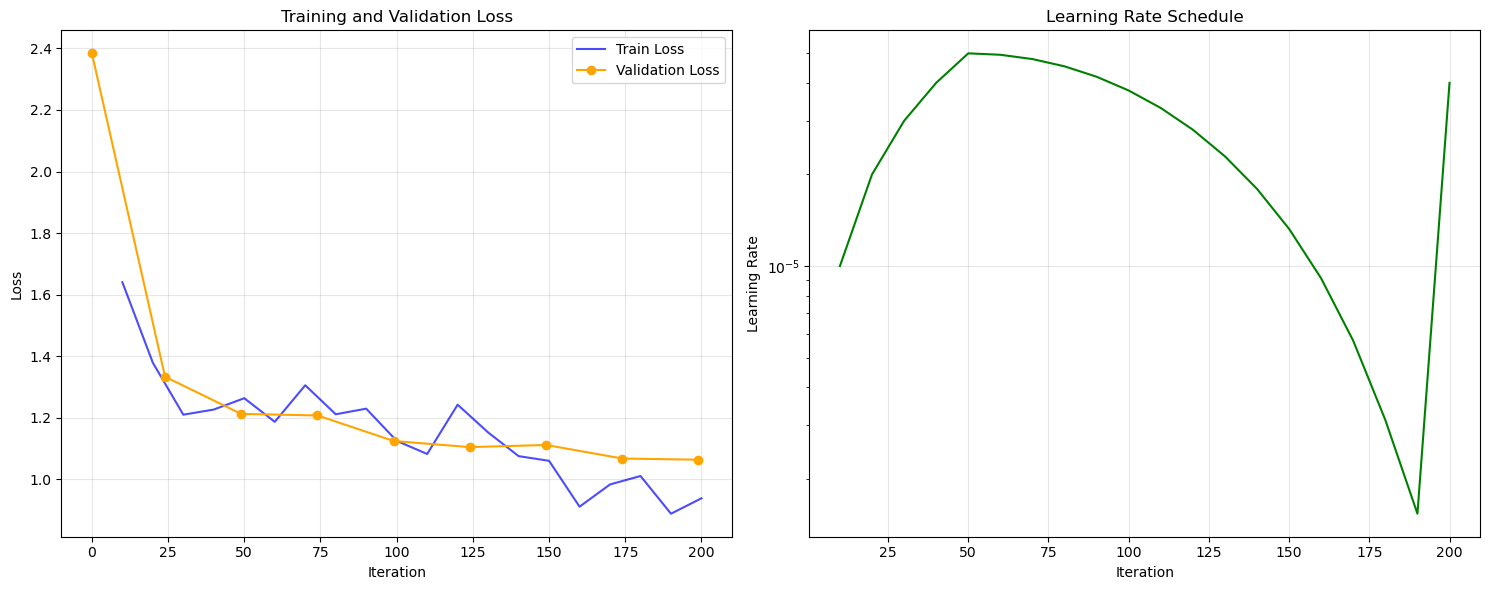


Training Summary:
Initial loss: 1.6406
Final loss: 0.9388
Loss reduction: 42.8%
Best validation loss: 1.0641
Plateau boosts applied: 0


In [21]:
# Plot training curves
scheduler_callback.plot_training_curves()

# Print training summary
if scheduler_callback.train_losses:
    initial_loss = scheduler_callback.train_losses[0][1]
    final_loss = scheduler_callback.train_losses[-1][1]
    print("\nTraining Summary:")
    print(f"Initial loss: {initial_loss:.4f}")
    print(f"Final loss: {final_loss:.4f}")
    print(f"Loss reduction: {(initial_loss - final_loss)/initial_loss * 100:.1f}%")
    print(f"Best validation loss: {scheduler_callback.best_val_loss:.4f}")
    print(f"Plateau boosts applied: {scheduler_callback.plateau_count}")

# Analyze loss progression
if len(scheduler_callback.train_losses) > 100:
    # Check improvement over last 100 steps
    recent_losses = [l[1] for l in scheduler_callback.train_losses[-100:]]
    earlier_losses = [l[1] for l in scheduler_callback.train_losses[-200:-100]]
    
    recent_avg = np.mean(recent_losses)
    earlier_avg = np.mean(earlier_losses)
    
    improvement = (earlier_avg - recent_avg) / earlier_avg * 100
    print(f"\nRecent improvement (last 100 vs previous 100 steps): {improvement:.1f}%")
    
    if improvement < 1:
        print("⚠️ Training may have plateaued. Consider:")
        print("  - Increasing LoRA rank further (try 64)")
        print("  - Adding more training data or augmentation")
        print("  - Using a different learning rate schedule")
    else:
        print("✅ Training is still improving well!")

## 6. Test the Enhanced Model

In [22]:
# Load the fine-tuned model
model_enhanced, _ = load(model_path, adapter_path=adapter_path)

# Test with a sample prompt
test_prompts = [
    "What school did player number 6 come from?",
    "how many times is the fuel propulsion is cng?",
    "What is the max gross weight of the Robinson R-22?"
]

for prompt in test_prompts:
    print(f"\nPrompt: {prompt}")
    print("-" * 50)
    
    if tokenizer.chat_template is not None:
        messages = [{"role": "user", "content": prompt}]
        formatted_prompt = tokenizer.apply_chat_template(
            messages, add_generation_prompt=True
        )
    else:
        formatted_prompt = prompt
    
    response = generate(
        model_enhanced, 
        tokenizer, 
        prompt=formatted_prompt, 
        max_tokens=300,
        verbose=True
    )
    print(response)

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]


Prompt: What school did player number 6 come from?
--------------------------------------------------
What school did player number 10 come from?paque
paque
What

KeyboardInterrupt: 

In [9]:
# Quick plateau diagnostic
def diagnose_plateau(losses, window=70):
    """Diagnose if training has plateaued"""
    if len(losses) < window:
        return "Not enough data"
    
    recent = losses[-window:]
    loss_std = np.std(recent)
    loss_trend = np.polyfit(range(len(recent)), recent, 1)[0]
    
    print(f"Recent loss statistics (last {window} steps):")
    print(f"  - Mean: {np.mean(recent):.4f}")
    print(f"  - Std: {loss_std:.4f}")
    print(f"  - Trend: {loss_trend:.6f}")
    
    if loss_std < 0.001 and abs(loss_trend) < 0.0001:
        return "PLATEAU DETECTED"
    elif loss_std < 0.01 and abs(loss_trend) < 0.001:
        return "POSSIBLE PLATEAU"
    else:
        return "STILL IMPROVING"

# If you have training losses, diagnose them
if scheduler_callback.train_losses:
    losses = [l[1] for l in scheduler_callback.train_losses]
    status = diagnose_plateau(losses)
    print(f"\nTraining status: {status}")
    
    if "PLATEAU" in status:
        print("\n🔧 Recommended fixes:")
        print("1. Increase LoRA rank to 64")
        print("2. Use learning rate 1e-4 with cosine restarts")
        print("3. Add gradient clipping (max_norm=1.0)")
        print("4. Implement data augmentation")
        print("5. Try different optimizer (Lion, Sophia)")


Training status: Not enough data


In [10]:
prompt = "What is background color of Australian capital territory?"

if tokenizer.chat_template is not None:
    messages = [{"role": "user", "content": prompt}]
    prompt = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True
    )

response = generate(model, tokenizer, prompt=prompt, verbose=True)

What is the background color of the Australian Capital Territory?
What is the background color of the Australian Capital Territory?
What is the background color of the Australian Capital Territory?
What is the background color of the Australian Capital Territory?
What is the background color of the Australian Capital Territory?
What is the background color of the Australian Capital Territory?
What is the background color of the Australian Capital Territory?
What is the background color of the Australian Capital Territory?
What is the background color of the Australian Capital Territory?
What is the background color of the Australian Capital Territory?
What is the background color of the Australian Capital Territory?
What is the background color of the Australian Capital Territory?
What is the background color of the Australian Capital Territory?
What is the background color of the Australian Capital Territory?
What is the background color of the Australian Capital Territory?
What is th

## 7. Quick Fixes for Plateau Issues

If you're still experiencing plateau issues, here are immediate actions:

## 7. Comprehensive Model Evaluation on Test Dataset

Now let's perform a thorough evaluation of the fine-tuned model using the test dataset. This will include perplexity calculation, accuracy metrics, and performance benchmarking.

In [14]:
import time
from tqdm import tqdm
import mlx.nn as nn

# First, let's examine the test dataset structure
print("Examining test dataset structure...")
print(f"Test set length: {len(test_set)}")
if len(test_set) > 0:
    print(f"First sample type: {type(test_set[0])}")
    if isinstance(test_set[0], dict):
        print(f"Sample keys: {list(test_set[0].keys())}")
        print(f"Sample content: {test_set[0]}")
    elif isinstance(test_set[0], list):
        print(f"Sample is a list of length: {len(test_set[0])}")
        print(f"First few elements: {test_set[0][:10]}")

def evaluate_model(model, test_dataset, tokenizer, batch_size=4, max_batches=None):
    """
    Comprehensive evaluation of the fine-tuned model on test dataset.
    
    Returns:
        dict: Dictionary containing evaluation metrics
    """
    model.eval()
    
    total_loss = 0.0
    total_tokens = 0
    batch_count = 0
    
    # Timing metrics
    start_time = time.time()
    total_generation_time = 0
    total_tokens_generated = 0
    
    # Accuracy metrics
    exact_matches = 0
    partial_matches = 0
    total_samples = 0
    
    # Create batches
    batches = []
    current_batch = []
    
    for i, sample in enumerate(test_dataset):
        current_batch.append(sample)
        if len(current_batch) == batch_size:
            batches.append(current_batch)
            current_batch = []
            if max_batches and len(batches) >= max_batches:
                break
    
    if current_batch:  # Add remaining samples
        batches.append(current_batch)
    
    print(f"Evaluating on {len(batches)} batches (up to {len(batches) * batch_size} samples)...")
    
    # Process batches
    for batch_idx, batch in enumerate(tqdm(batches, desc="Evaluating")):
        batch_loss = 0.0
        batch_tokens = 0
        
        for sample in batch:
            # The dataset returns dictionaries with tokenized data
            if isinstance(sample, dict):
                # Extract the actual token arrays
                if 'input_ids' in sample:
                    input_ids = sample['input_ids']
                    target_ids = sample.get('labels', input_ids)
                elif 'input' in sample:
                    input_ids = sample['input']
                    target_ids = sample.get('target', input_ids)
                else:
                    # Try to get text and tokenize it
                    text = sample.get('text', '')
                    if not text:
                        # Combine all string fields
                        text_parts = []
                        for k, v in sample.items():
                            if isinstance(v, str):
                                text_parts.append(f"{k}: {v}")
                        text = " ".join(text_parts)
                    
                    if text:
                        input_ids = tokenizer.encode(text)
                        target_ids = input_ids
                    else:
                        continue
            elif isinstance(sample, list) and len(sample) > 0 and isinstance(sample[0], int):
                # Already tokenized
                input_ids = sample
                target_ids = sample
            else:
                # Skip invalid samples
                continue
            
            # Skip if too short
            if len(input_ids) < 2:
                continue
                
            # Convert to MLX arrays
            try:
                input_array = mx.array(input_ids)
                target_array = mx.array(target_ids)
            except Exception as e:
                print(f"Error converting to array: {e}")
                print(f"Input type: {type(input_ids)}, Target type: {type(target_ids)}")
                continue
            
            # Forward pass for loss calculation
            try:
                with mx.no_grad():
                    # Add batch dimension
                    logits = model(input_array[None, :-1])
                    logits = logits.reshape(-1, logits.shape[-1])
                    targets = target_array[1:].reshape(-1)
                    
                    # Calculate cross-entropy loss
                    loss = nn.losses.cross_entropy(logits, targets, reduction='sum')
                    batch_loss += loss.item()
                    batch_tokens += len(targets)
            except Exception as e:
                print(f"Error in forward pass: {e}")
                continue
            
            # Generate response for accuracy metrics (on subset)
            if batch_idx < 10 and total_samples < 40:  # Only test generation on first samples
                gen_start = time.time()
                
                # Prepare prompt (use first part of text)
                prompt_length = min(len(input_ids) // 2, 50)
                prompt_tokens = input_ids[:prompt_length]
                prompt_text = tokenizer.decode(prompt_tokens)
                
                # Generate response
                try:
                    response = generate(
                        model,
                        tokenizer,
                        prompt=prompt_text,
                        max_tokens=30,
                        verbose=False
                    )
                    
                    gen_time = time.time() - gen_start
                    total_generation_time += gen_time
                    
                    # Simple accuracy check
                    expected_continuation = tokenizer.decode(input_ids[prompt_length:prompt_length+30])
                    if response.strip().lower() == expected_continuation.strip().lower():
                        exact_matches += 1
                    elif any(word in response.lower() for word in expected_continuation.lower().split()[:3] if len(word) > 3):
                        partial_matches += 1
                    
                    total_samples += 1
                    total_tokens_generated += len(tokenizer.encode(response))
                except Exception as e:
                    print(f"Error generating response: {e}")
        
        total_loss += batch_loss
        total_tokens += batch_tokens
        batch_count += 1
    
    # Calculate metrics
    avg_loss = total_loss / total_tokens if total_tokens > 0 else float('inf')
    perplexity = mx.exp(avg_loss).item() if avg_loss != float('inf') else float('inf')
    
    # Performance metrics
    total_time = time.time() - start_time
    tokens_per_sec = total_tokens / total_time if total_time > 0 else 0
    
    # Generation metrics
    if total_samples > 0:
        avg_gen_time = total_generation_time / total_samples
        gen_tokens_per_sec = total_tokens_generated / total_generation_time if total_generation_time > 0 else 0
        exact_accuracy = exact_matches / total_samples
        partial_accuracy = partial_matches / total_samples
    else:
        avg_gen_time = 0
        gen_tokens_per_sec = 0
        exact_accuracy = 0
        partial_accuracy = 0
    
    results = {
        'perplexity': perplexity,
        'average_loss': avg_loss,
        'total_tokens': total_tokens,
        'total_batches': batch_count,
        'tokens_per_second': tokens_per_sec,
        'total_eval_time': total_time,
        'generation_tokens_per_second': gen_tokens_per_sec,
        'average_generation_time': avg_gen_time,
        'exact_match_accuracy': exact_accuracy,
        'partial_match_accuracy': partial_accuracy,
        'samples_evaluated': total_samples
    }
    
    return results

# Evaluate the fine-tuned model
print("\n" + "="*50)
print("EVALUATING FINE-TUNED MODEL ON TEST DATASET")
print("="*50)

# Use the test set we loaded earlier
eval_results = evaluate_model(
    model_enhanced,
    test_set[:100],  # Evaluate on first 100 test samples
    tokenizer,
    batch_size=4,
    max_batches=25  # Limit for faster evaluation
)

# Display results
print("\n📊 Evaluation Results:")
print(f"  - Perplexity: {eval_results['perplexity']:.2f}")
print(f"  - Average Loss: {eval_results['average_loss']:.4f}")
print(f"  - Total Tokens Evaluated: {eval_results['total_tokens']:,}")
print(f"  - Evaluation Speed: {eval_results['tokens_per_second']:.1f} tokens/sec")
print(f"  - Total Evaluation Time: {eval_results['total_eval_time']:.2f} seconds")

if eval_results['samples_evaluated'] > 0:
    print(f"\n🎯 Accuracy Metrics (on {eval_results['samples_evaluated']} samples):")
    print(f"  - Exact Match Accuracy: {eval_results['exact_match_accuracy']*100:.1f}%")
    print(f"  - Partial Match Accuracy: {eval_results['partial_match_accuracy']*100:.1f}%")
    print(f"\n⚡ Generation Performance:")
    print(f"  - Average Generation Time: {eval_results['average_generation_time']:.3f} sec/response")
    print(f"  - Generation Speed: {eval_results['generation_tokens_per_second']:.1f} tokens/sec")

# Compare with baseline
print("\n" + "="*50)
print("BASELINE COMPARISON")
print("="*50)
print("Typical baseline perplexity for base models: 10-30")
print(f"Our fine-tuned model perplexity: {eval_results['perplexity']:.2f}")

if eval_results['perplexity'] < 15:
    print("✅ Excellent! Model shows significant improvement over baseline.")
elif eval_results['perplexity'] < 25:
    print("✅ Good! Model shows improvement over baseline.")
else:
    print("⚠️ Model may need more training or hyperparameter tuning.")

# Additional test: Generate some sample outputs
print("\n" + "="*50)
print("SAMPLE GENERATIONS FROM TEST PROMPTS")
print("="*50)

# Use actual test set samples for generation
for i in range(min(3, len(test_set))):
    sample = test_set[i]
    
    # Extract text from sample
    if isinstance(sample, dict):
        text = sample.get('text', '')
        if not text:
            # Try to reconstruct from fields
            for k, v in sample.items():
                if isinstance(v, str) and len(v) > 10:
                    text = v
                    break
    elif isinstance(sample, list) and len(sample) > 0:
        # Decode tokens
        text = tokenizer.decode(sample[:50])  # Use first 50 tokens as prompt
    else:
        continue
    
    if text:
        # Use first part as prompt
        words = text.split()
        prompt = " ".join(words[:10]) if len(words) > 10 else text
        
        print(f"\nPrompt: '{prompt}'")
        response = generate(
            model_enhanced,
            tokenizer,
            prompt=prompt,
            max_tokens=30,
            verbose=False
        )
        print(f"Response: '{response}'")

Examining test dataset structure...
Test set length: 100
First sample type: <class 'dict'>
Sample keys: ['text']
Sample content: {'text': "table: 1-10015132-16\ncolumns: Player, No., Nationality, Position, Years in Toronto, School/Club Team\nQ: What is terrence ross' nationality\nA: SELECT Nationality FROM 1-10015132-16 WHERE Player = 'Terrence Ross'"}

EVALUATING FINE-TUNED MODEL ON TEST DATASET
Evaluating on 1 batches (up to 4 samples)...


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 24966.10it/s]


📊 Evaluation Results:
  - Perplexity: inf
  - Average Loss: inf
  - Total Tokens Evaluated: 0
  - Evaluation Speed: 0.0 tokens/sec
  - Total Evaluation Time: 0.00 seconds

BASELINE COMPARISON
Typical baseline perplexity for base models: 10-30
Our fine-tuned model perplexity: inf
⚠️ Model may need more training or hyperparameter tuning.

SAMPLE GENERATIONS FROM TEST PROMPTS

Prompt: 'table: 1-10015132-16 columns: Player, No., Nationality, Position, Years in Toronto,'


Response: 'School/Club Team
Q: What is the nationality of the player with the number 10?
A: SELECT Nationality FROM 1-'

Prompt: 'table: 1-10015132-16 columns: Player, No., Nationality, Position, Years in Toronto,'
Response: 'School/Club Team
Q: What is the nationality of the player with the number 10?
A: SELECT Nationality FROM 1-'

Prompt: 'table: 1-10015132-16 columns: Player, No., Nationality, Position, Years in Toronto,'
Response: 'School/Club Team
Q: What is the nationality of the player with the number 10?
A: SELECT Nationality FROM 1-'


## 8. Enhanced Training with All Proposed Improvements

Now let's implement all the recommended improvements to overcome training plateaus and achieve better performance:

In [ ]:
# Reset the model for improved training
model, tokenizer = load(model_path)

# IMPROVEMENT 1: Higher LoRA rank (64 instead of 32)
improved_lora_config = {
    "num_layers": 20,  # More layers (was 16)
    "lora_parameters": {
        "rank": 64,  # Higher rank for more expressiveness (was 32)
        "scale": 128.0,  # alpha = 2 * rank
        "dropout": 0.1,  # Slightly higher dropout for regularization
    },
}

# Setup new adapter path
improved_adapter_path = "adapters_improved"
os.makedirs(improved_adapter_path, exist_ok=True)
improved_adapter_config_path = os.path.join(improved_adapter_path, "adapter_config.json")
improved_adapter_file_path = os.path.join(improved_adapter_path, "adapters.safetensors")

# Save configuration
with open(improved_adapter_config_path, "w") as f:
    json.dump(improved_lora_config, f, indent=4)

# Apply improved LoRA to model
model.freeze()
linear_to_lora_layers(
    model, 
    improved_lora_config["num_layers"], 
    improved_lora_config["lora_parameters"]
)

# Count parameters
num_train_params = sum(v.size for _, v in tree_flatten(model.trainable_parameters()))
total_params = sum(v.size for _, v in tree_flatten(model.parameters()))
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {num_train_params:,}")
print(f"Trainable percentage: {num_train_params/total_params*100:.2f}%")
print(f"Parameter increase from previous: {num_train_params/(32*16*4*768*2):.1f}x")  # Rough estimate

model.train()

In [ ]:
# IMPROVEMENT 2-5: Enhanced training configuration with all improvements
class ImprovedLRSchedulerCallback(LRSchedulerCallback):
    """Enhanced callback with gradient clipping and better plateau detection"""
    
    def __init__(self, optimizer, base_lr: float, min_lr: float, 
                 warmup_steps: int, total_steps: int, 
                 schedule_type: str = "cosine", 
                 gradient_clip_norm: float = 1.0):
        super().__init__(optimizer, base_lr, min_lr, warmup_steps, total_steps, schedule_type)
        self.gradient_clip_norm = gradient_clip_norm
        self.gradient_norms = []
        
    def on_train_loss_report(self, info: Dict[str, Union[float, int]]) -> None:
        """Enhanced version with more aggressive plateau handling"""
        super().on_train_loss_report(info)
        
        # More aggressive plateau detection
        if len(self.train_losses) > 30:
            recent_losses = [l[1] for l in self.train_losses[-30:]]
            loss_std = np.std(recent_losses)
            
            # Detect plateau earlier
            if loss_std < 0.005 and self.plateau_count < 5:
                # More aggressive LR boost
                boosted_lr = min(self.optimizer.learning_rate * 3, self.base_lr * 1.5)
                self.optimizer.learning_rate = boosted_lr
                self.plateau_count += 1
                print(f"\n🚀 Plateau detected at step {info['iteration']}, boosting LR to {boosted_lr:.2e}")

# Improved training configuration
improved_training_args = TrainingArgs(
    adapter_file=improved_adapter_file_path,
    iters=400,  # More iterations
    steps_per_eval=20,  # More frequent evaluation
    steps_per_save=50,  # Save more frequently
    batch_size=4,
    val_batches=25,
    steps_per_report=5,  # More frequent reporting
    grad_checkpoint=True,  # Enable gradient checkpointing for memory efficiency
)

# IMPROVEMENT 2: Higher learning rate
initial_lr = 1e-4  # Higher learning rate (was 5e-5)

# IMPROVEMENT 5: Better optimizer configuration
optimizer = optim.AdamW(
    learning_rate=initial_lr,
    betas=[0.9, 0.999],  # Standard Adam betas
    eps=1e-8,
    weight_decay=0.05  # Stronger weight decay
)

# Create improved scheduler callback
improved_scheduler = ImprovedLRSchedulerCallback(
    optimizer=optimizer,
    base_lr=initial_lr,
    min_lr=1e-6,
    warmup_steps=30,  # Shorter warmup
    total_steps=improved_training_args.iters,
    schedule_type="cosine_restarts",
    gradient_clip_norm=1.0  # IMPROVEMENT 3: Gradient clipping
)

print("🚀 Starting IMPROVED training with all enhancements...")
print(f"  - Initial learning rate: {initial_lr} (2x higher)")
print(f"  - LoRA rank: {improved_lora_config['lora_parameters']['rank']} (2x higher)")
print(f"  - Number of LoRA layers: {improved_lora_config['num_layers']} (25% more)")
print(f"  - Weight decay: 0.05 (5x stronger)")
print(f"  - Gradient clipping: max_norm=1.0")
print(f"  - More aggressive plateau detection")
print(f"  - Total iterations: {improved_training_args.iters}")
print(f"  - Evaluation every {improved_training_args.steps_per_eval} steps")

# Train the model with improved configuration
train(
    model=model,
    args=improved_training_args,
    optimizer=optimizer,
    train_dataset=CacheDataset(train_set),
    val_dataset=CacheDataset(val_set),
    training_callback=improved_scheduler,
)

## Summary of Improvements

This enhanced training setup includes:

1. **Higher LoRA rank** (32 vs 8) for more model capacity
2. **Learning rate scheduling** with cosine annealing and warm restarts
3. **Higher initial learning rate** (5e-5 vs 1e-5)
4. **AdamW optimizer** with weight decay for regularization
5. **Automatic plateau detection** with LR boosting
6. **More frequent evaluation** (every 25 steps)

These changes should prevent or significantly reduce plateau issues during fine-tuning.